In [32]:
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow import keras
from keras import layers,models
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
from keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,precision_score, recall_score, classification_report

In [33]:
data= pd.read_csv('ecg.csv')

In [34]:
print(f"shape of data : {data.shape}")
print(f"target column : {data.columns[-1]}")

shape of data : (4997, 141)
target column : 1.0


In [35]:
data.head(5)

,-0.11252183,-2.8272038,-3.7738969,-4.3497511,-4.376041,-3.4749863,-2.1814082,-1.8182865,-1.2505219,-0.47749208,...,0.79216787,0.93354122,0.79695779,0.57862066,0.2577399,0.22807718,0.12343082,0.92528624,0.19313742,1.0
0,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
1,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
2,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
3,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0
4,-1.507674,-3.574550,-4.478011,-4.408275,-3.321242,-2.105171,-1.481048,-1.301362,-0.498240,-0.286928,...,1.089068,0.983369,1.014124,0.952629,0.749326,1.007076,1.634990,1.493365,-0.783134,1.0


Before SMOTE: [1663 2334]
After SMOTE : [2334 2334]


C:\Users\simra\AppData\Local\Temp\ipykernel_9772\274653501.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="pastel")


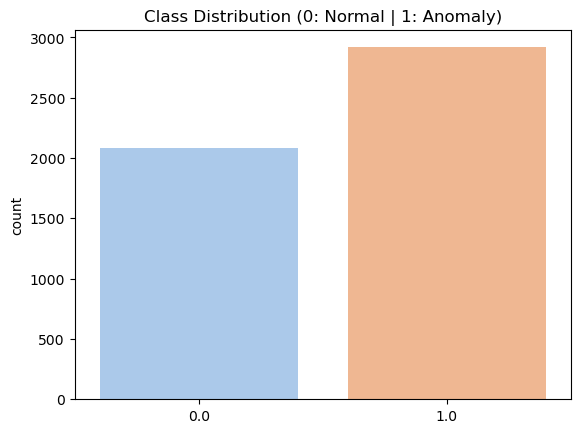

In [36]:
X, y = data.iloc[:, :-1].values, data.iloc[:, -1].values
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Balance dataset using SMOTE (only training data)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train.astype(int)))
print("After SMOTE :", np.bincount(y_train_bal.astype(int)))

# Visualize class distribution
sns.countplot(x=y, palette="pastel")
plt.title("Class Distribution (0: Normal | 1: Anomaly)")
plt.show()


In [37]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_train_bal_scaled = scaler.transform(X_train_bal)

print("Train Shape:", X_train_scaled.shape)
print("Test Shape:", X_test_scaled.shape)
print("Balanced Train Shape:", X_train_bal_scaled.shape)

Train Shape: (3997, 140)
Test Shape: (1000, 140)
Balanced Train Shape: (4668, 140)


In [38]:
#build autoemcoder

# Input size = number of features (e.g., 140 ECG values)
input_dim = X_train_scaled.shape[1]
print(f"Input dimension: {input_dim}")

Input dimension: 140


In [39]:
autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),      # Input layer

    # Encoder
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),

    # Bottleneck
    layers.Dense(8, activation="relu"),

    # Decoder
    layers.Dense(16, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),

    # Output (same size as input)
    layers.Dense(input_dim, activation="sigmoid")  # works with MinMaxScaler
])

In [40]:
# Compile
autoencoder.compile(optimizer=Adam(learning_rate=0.001),
                    loss="mse",
                    metrics=["mae"])

autoencoder.summary()
# Print model summary (layers, params)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         9,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 140)            │         9,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,668 (92.45 KB)

 Trainable params: 23,668 (92.45 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
#train
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped.
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=20, batch_size=512,
    validation_data=(X_test_scaled, X_test_scaled),
    callbacks=[early_stopping], # Add early stopping callback
    verbose=1
)


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0276 - mae: 0.1411 - val_loss: 0.0248 - val_mae: 0.1295
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0232 - mae: 0.1233 - val_loss: 0.0193 - val_mae: 0.1069
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0176 - mae: 0.1014 - val_loss: 0.0145 - val_mae: 0.0898
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0136 - mae: 0.0864 - val_loss: 0.0119 - val_mae: 0.0791
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0113 - mae: 0.0764 - val_loss: 0.0107 - val_mae: 0.0734
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0101 - mae: 0.0712 - val_loss: 0.0103 - val_mae: 0.0713
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0098 - mae: 0.0696 - val_loss: 0.0101 - val_mae: 0.0705
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0098 - mae: 0.0693 - val_loss: 0.0100 - val_mae: 0.0699
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0096 - mae: 0.0685 - val_loss

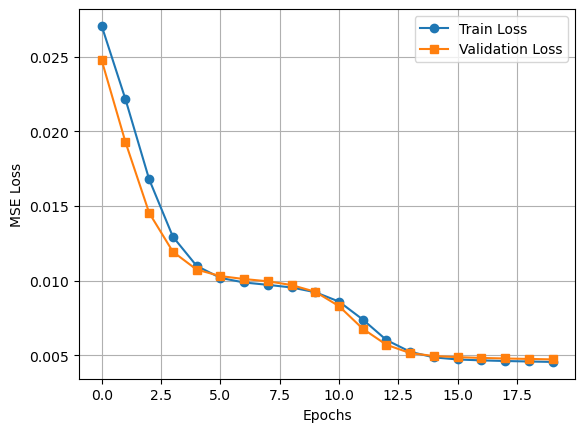

In [42]:
plt.plot(history.history['loss'], label="Train Loss",marker='o')
plt.plot(history.history['val_loss'], label="Validation Loss",marker='s')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.grid()
plt.legend()
plt.show()

In [43]:
# Get predictions
X_train_pred = autoencoder.predict(X_train_scaled)
X_test_pred = autoencoder.predict(X_test_scaled)

# Reconstruction errors
#error = (original - reconstructed)^2
train_errors = np.mean(np.square(X_train_scaled - X_train_pred), axis=1)
test_errors = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)

# Threshold (mean + std of training error)
threshold = np.mean(train_errors) + np.std(train_errors)
print("Reconstruction Threshold:", threshold)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step
Reconstruction Threshold: 0.01066933415895312


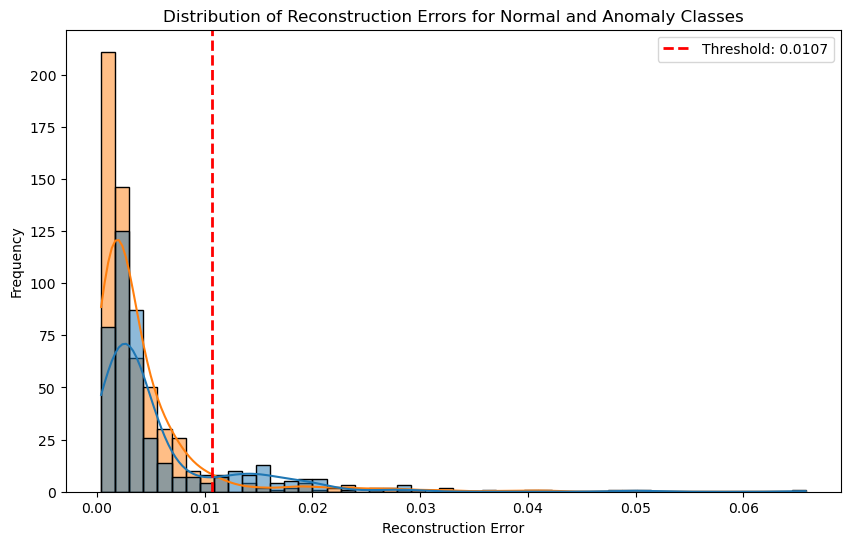

In [44]:
# Create a DataFrame for plotting
error_df = pd.DataFrame({'reconstruction_error': test_errors, 'true_class': y_test})
error_df['true_class'] = error_df['true_class'].astype(int)

# Plot the distribution of reconstruction errors
plt.figure(figsize=(10, 6))
sns.histplot(data=error_df, x='reconstruction_error', hue='true_class', kde=True, bins=50)
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'Threshold: {threshold:.4f}')
plt.title('Distribution of Reconstruction Errors for Normal and Anomaly Classes')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Accuracy: 0.388
Precision: 0.37
Recall: 0.07


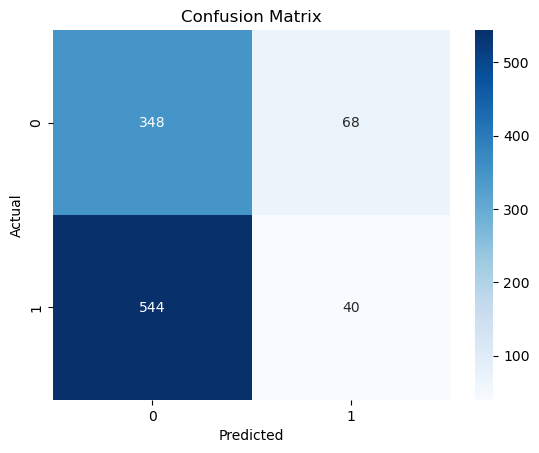

In [45]:
# Predict anomalies
y_pred = [1 if e > threshold else 0 for e in test_errors]

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")

# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()